In [1]:
%matplotlib widget
import ipywidgets as widgets
# from IPython.display import clear_output
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
# import seaborn as sns
# import pandas as pd
# import numpy as np
from tqdm.autonotebook import tqdm
from scipy.ndimage import gaussian_filter1d
# import h5py
# import copy
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

# import shlex

from diffSPH.simple import *
from util import *

# from waveEqn import WaveEquationState, waveEquation2
# from waveEqn import WaveSystem, waveSystemFunction

In [85]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
device = torch.device('cpu')
dtype = torch.float32
L = 2
dim = 2
nx = 256

kernel = KernelType.Wendland4
targetNeighbors = n_h_to_nH(4, dim)

print(f'Using device: {device}')
print(f'Using dtype: {dtype}')
print(f'Number of particles: {nx**dim} [{dim}D grid with {nx}^{{{dim}}} particles]')
print(f'Kernel: {kernel.name}, Target Neighbors: {targetNeighbors}')

domain = buildDomainDescription(L, dim, True, device, dtype)

# particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0.2, 128, shiftScheme = 'delta')
particles = sampleOptimal(nx, domain, targetNeighbors, kernel, 0., 0, shiftScheme = 'delta')

config = {
    'domain': domain,
    'kernel': kernel,
    'targetNeighbors': targetNeighbors,
    'neighborhood':{
        'verletScale': 1.0,
        'computeHessian': True,
    }
}

config['gradientMode'] = GradientMode.Difference
config['laplacianMode'] = LaplacianMode.Brookshaw
config['supportScheme'] = SupportScheme.Gather
config['integrationScheme'] = IntegrationSchemeType.rungeKutta4

Using device: cpu
Using dtype: torch.float32
Number of particles: 65536 [2D grid with 256^{2} particles]
Kernel: Wendland4, Target Neighbors: 50.26548245743669


0it [00:00, ?it/s]

In [86]:
sampledPositions = particles.positions.clone()
particles = particles._replace(positions = torch.rand_like(particles.positions) * (domain.max - domain.min) + domain.min)

In [87]:
from diffSPH.neighborhood import buildNeighborhood, computeNeighborhoodStates, filterNeighborhoodByKind, coo_to_csr
import numpy as np


mode = SupportScheme.SuperSymmetric
mode_str = mode.name
mode_str = mode_str[0].lower() + mode_str[1:]
particleState = wcstateToState(particles)
k_ = 2
u_mag = 1.0


ktgv = k_ / 2
if k_ % 2 == 0:
    phaseShift_x = np.pi / 2# / k
    phaseShift_y = np.pi / 2# / k
else:
    phaseShift_x = 0
    phaseShift_y = 0

particleState.velocities[:,0] =  u_mag * torch.cos(ktgv * np.pi * particleState.positions[:,0] + phaseShift_x) * torch.sin(ktgv * np.pi * particleState.positions[:,1] + phaseShift_y)
particleState.velocities[:,1] = -u_mag * torch.sin(ktgv * np.pi * particleState.positions[:,0] + phaseShift_x) * torch.cos(ktgv * np.pi * particleState.positions[:,1] + phaseShift_y)

original_positions = particleState.positions.clone()

neighborhood, sparseNeighborhood_ = buildNeighborhood(particles, particles, domain, verletScale = 1.4, mode = mode_str, priorNeighborhood=None)
neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)

numNeighbors = coo_to_csr(neighbors.neighbors).rowEntries
particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)


print('Number of neighbors:', numNeighbors.shape, numNeighbors)


Number of neighbors: torch.Size([65536]) tensor([48, 61, 61,  ..., 51, 38, 47])


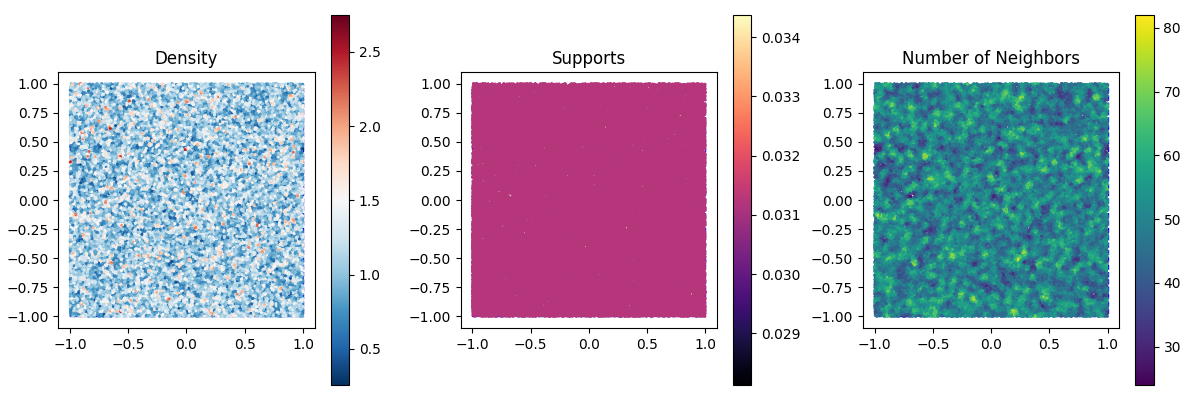

In [88]:
fig, axis = plt.subplots(1,3 , figsize=(12,4), squeeze=False)
markerSize = 1
visualizeParticles(fig, axis[0,0], particleState, config['domain'], particleState.densities,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu_r', markerSize = markerSize, gridVisualization = False, title = 'Density')

visualizeParticles(fig, axis[0,1], particleState, config['domain'], particleState.supports,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', markerSize = markerSize, gridVisualization = False, title = 'Supports')

visualizeParticles(fig, axis[0,2], particleState, config['domain'], numNeighbors,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'viridis', markerSize = markerSize, gridVisualization = False, title = 'Number of Neighbors')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()

In [89]:
dx = L / nx
dxScaling = dx / (2 * np.pi)**(1/dim)
print(f'Particle spacing dx: {dx}')

dx_r = lambda r: 1/(2 - torch.clamp(torch.linalg.norm(r, dim=-1), min = 0, max = 1)) * dx
dx_r = lambda r: torch.where(torch.linalg.norm(r, dim=-1) < 0.5, 1/2, 1) * dx
dx_r = lambda r: torch.ones_like(r[:,0]) * dx
h_r = lambda r: volumeToSupport(dx_r(r)**dim, targetNeighbors, dim)

Particle spacing dx: 0.0078125


In [90]:
print(volumeToSupport(dx**dim, targetNeighbors, dim))
print(volumeToSupport(dx_r(torch.zeros(1,dim))**dim, targetNeighbors, dim))

0.03125
tensor([0.0312])


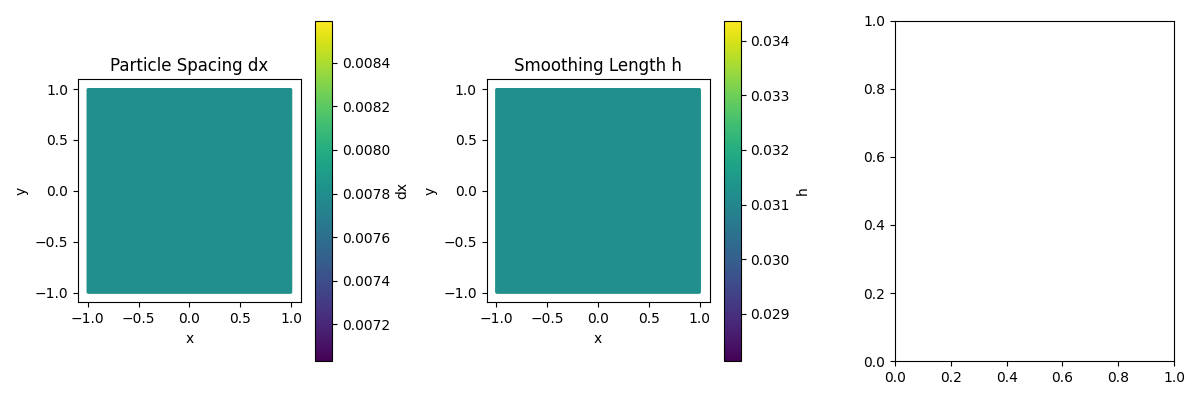

In [91]:
fig, axis = plt.subplots(1,3 , figsize=(12,4), squeeze=False)
markerSize = 1

dx_sampled = dx_r(sampledPositions)
h_sampled = h_r(sampledPositions)

sc = axis[0,0].scatter(sampledPositions[:,0].cpu(), sampledPositions[:,1].cpu(), s=markerSize, c=dx_sampled, label='Sampled')
fig.colorbar(sc, ax=axis[0,0], label='dx')
axis[0,0].set_title('Particle Spacing dx')
axis[0,0].set_xlabel('x')
axis[0,0].set_ylabel('y')
axis[0,0].set_aspect('equal', 'box')



sc = axis[0,1].scatter(sampledPositions[:,0].cpu(), sampledPositions[:,1].cpu(), s=markerSize, c=h_sampled, label='Sampled')
fig.colorbar(sc, ax=axis[0,1], label='h')
axis[0,1].set_title('Smoothing Length h')
axis[0,1].set_xlabel('x')
axis[0,1].set_ylabel('y')
axis[0,1].set_aspect('equal', 'box')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()

In [92]:
from diffSPH.kernels import Kernel
import numpy as np

In [93]:
neighs = neighbors.get('noghost')

mu = 0.1
epsilon = 1e-3

def f(h_ij, r_ij):    
    return torch.where(h_ij > r_ij, (h_ij / (2 * r_ij + epsilon))**2 -1/4, torch.zeros_like(r_ij))
    return 

h_i = particleState.supports[neighs[0].row]
h_j = particleState.supports[neighs[0].col]
h_ij = 0.5 * (h_i + h_j)
r_ij = neighs[1].r_ij
x_ij = neighs[1].x_ij / (r_ij.unsqueeze(1) + 1e-10)

print(r_ij.max())
print(torch.linalg.norm(x_ij, dim=1).max())
print(h_ij.max(), h_ij.min())

f(h_ij, r_ij).min(), f(h_ij, r_ij).max()

f_ij = f(h_ij, r_ij)
f_ij = Kernel(kernel, neighs[1].x_ij, h_ij)

delta_x = mu * f_ij.unsqueeze(1) * x_ij * h_i.unsqueeze(1)
delta_x_norm = torch.linalg.norm(delta_x, dim=1)
delta_x_norm.max(), delta_x_norm.mean(), delta_x_norm.min()

v_SPH = np.pi * h_i**2
V_SPH = torch.sum(v_SPH) / targetNeighbors**dim
V = L**dim
print(f'Total SPH Volume: {V_SPH}, Domain Volume: {L**dim}, Ratio: {V_SPH/V}')

h_ri = h_r(particleState.positions)
v_ri = np.pi * (h_ri**dim) / targetNeighbors
V_r = torch.sum(v_ri)
print(f'Total Reference Volume: {V_r}, Domain Volume: {L**dim}, Ratio: {V_r/V}')

ratio = V_r / V
scaling = (ratio)**(1/dim)
print(f'Scaling factor: {scaling}, Adjusted Ratio: {(V_r / scaling**dim)/V}')
scaled_h = h_ri / scaling
scaled_v = np.pi * (scaled_h**dim) / targetNeighbors
V_s = torch.sum(scaled_v)
print(f'Total Scaled Reference Volume: {V_s}, Domain Volume: {L**dim}, Ratio: {V_s/V}')



tensor(0.0312)
tensor(1.0000)
tensor(0.0312) tensor(0.0312)
Total SPH Volume: 4.081902027130127, Domain Volume: 4, Ratio: 1.0204755067825317
Total Reference Volume: 4.0, Domain Volume: 4, Ratio: 1.0
Scaling factor: 1.0, Adjusted Ratio: 1.0
Total Scaled Reference Volume: 4.0, Domain Volume: 4, Ratio: 1.0


In [94]:
from diffSPH.operations import scatter_sum

In [95]:
def wvt_step(particleState, neighborhood):
    # neighborhood, sparseNeighborhood_ = buildNeighborhood(particleState, particleState, domain, verletScale = 1.0, mode = mode_str, priorNeighborhood=neighborhood)
    # neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)
    # particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)
    
    # neighs = neighbors.get('noghost')

    # h_i = particleState.supports[neighs[0].row]
    # h_j = particleState.supports[neighs[0].col]
    
    # h_i = h_r(particleState.positions[neighs[0].row])
    # h_j = h_r(particleState.positions[neighs[0].col])
            
    h_ri = h_r(particleState.positions)
    
    dxi = dx_r(particleState.positions)
    
    v_ri = np.pi * (h_ri**dim) / targetNeighbors
    v_ri = dxi**dim
    V_r = torch.sum(v_ri)
    
    
    V_r = torch.sum(v_ri)
    # print(f'Total Reference Volume: {V_r}, Domain Volume: {L**dim}, Ratio: {V_r/V}')
    ratio = V_r / V
    scaling = (ratio)#**(1/dim)
    # print(f'Scaling factor: {scaling}, Adjusted Ratio: {(V_r / scaling**dim)/V}')
    
    scaled_h = h_ri / scaling
    scaled_v = dxi**dim / scaling
    # scaled_v = np.pi * (scaled_h**dim) / targetNeighbors
    V_s = torch.sum(scaled_v)
    # print(f'Total Scaled Reference Volume: {V_s}, Domain Volume: {L**dim}, Ratio: {V_s/V}')
    
    h_ri = volumeToSupport(dxi**dim / scaling, targetNeighbors, dim)
    particleState.supports = h_ri
    
    neighborhood, sparseNeighborhood_ = buildNeighborhood(particleState, particleState, domain, verletScale = 1.0, mode = mode_str, priorNeighborhood=neighborhood)
    neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, mode_str, kernel, kernel, True, False, False)
    particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)
    
    neighs = neighbors.get('noghost')
    
    h_i = h_ri[neighs[0].row] / scaling
    h_j = h_ri[neighs[0].col] / scaling
    
    h_ij = 0.5 * (h_i + h_j)
    r_ij = neighs[1].r_ij
    x_ij = neighs[1].x_ij / (r_ij.unsqueeze(1) + 1e-10)

    # f_ij = f(h_ij, r_ij)
    f_ij = Kernel(kernel, neighs[1].x_ij, h_ij)

    delta_x = mu * f_ij.unsqueeze(1) * x_ij * h_i.unsqueeze(1)
    delta_x = scatter_sum(delta_x, neighs[0].row, dim_size=particleState.positions.shape[0], dim = 0)
    
    dx_mean = scatter_sum(r_ij, neighs[0].row, dim_size=particleState.positions.shape[0], dim = 0) / (numNeighbors + 1e-10)
    
    max_norm = torch.linalg.norm(delta_x, dim=1).max()

    clamped_norm = torch.clamp(torch.linalg.norm(delta_x, dim=1), max=0.5 * h_i.max())
    delta_x = delta_x * ((clamped_norm / (torch.linalg.norm(delta_x, dim=1) + 1e-10)).unsqueeze(1))

    # print(f'Maximum displacement: {max_norm} (should be < {mu*h_i.max()})')
    # if max_norm > h_i.max():
        # delta_x = delta_x * (h_i.max() / max_norm)
        

    # new_positions = particleState.positions + delta_x
    # new_velocities = particleState.velocities
    return delta_x, h_ri, neighborhood,dx_mean

In [96]:
# original_positions = particleState.positions.clone()
original_positions = sampledPositions.clone()
original_positions = torch.rand_like(particles.positions) * (domain.max - domain.min) + domain.min

In [97]:

dx = L / nx
dxScaling = dx / (2 * np.pi)**(1/dim)
print(f'Particle spacing dx: {dx}')

dx_r = lambda r: 1/(2 - torch.clamp(torch.linalg.norm(r, dim=-1), min = 0, max = 0.5)) * dx
dx_r = lambda r: torch.where(torch.linalg.norm(r, dim=-1) < 0.5, 1/2, 1) * dx
dx_r = lambda r: (2+torch.sin(np.pi *r[:,0])) * dx
dx_r = lambda r: torch.ones_like(r[:,0]) * dx
h_r = lambda r: volumeToSupport(dx_r(r)**dim, targetNeighbors, dim)

Particle spacing dx: 0.0078125


In [98]:
mu_initial = 1e-3
mu_decay = 0.95
mu = mu_initial
particleState.positions = original_positions.clone()
positions = []
dxs = []
mean_dxs = []
hs = []
positions.append(original_positions.cpu().numpy())
nIter = 256

for i in range(nIter):
    
    dx_step, h, neighborhood,dx_mean = wvt_step(particleState, neighborhood)
    particleState.positions = particleState.positions + dx_step
    particleState.supports = h
    dxs.append(dx_step.cpu().numpy())
    mean_dxs.append(dx_mean.cpu().numpy())
    hs.append(h.cpu().numpy())
    positions.append(particleState.positions.cpu().numpy())

    mu *= mu_decay
    
    print(f'WVT Step {i+1}/{nIter}, max dx: {dx_step.abs().max()}, mean dx: {dx_step.abs().mean()}')
    
    

WVT Step 1/256, max dx: 0.015625, mean dx: 0.009912364184856415
WVT Step 2/256, max dx: 0.015625, mean dx: 0.009929479099810123
WVT Step 3/256, max dx: 0.015625, mean dx: 0.009924412705004215
WVT Step 4/256, max dx: 0.015625, mean dx: 0.009916692972183228
WVT Step 5/256, max dx: 0.015625, mean dx: 0.009914999827742577
WVT Step 6/256, max dx: 0.015625, mean dx: 0.009921550750732422
WVT Step 7/256, max dx: 0.015625, mean dx: 0.009918528608977795
WVT Step 8/256, max dx: 0.015625, mean dx: 0.009922188706696033
WVT Step 9/256, max dx: 0.015625, mean dx: 0.009911024011671543
WVT Step 10/256, max dx: 0.015625, mean dx: 0.009908120147883892
WVT Step 11/256, max dx: 0.015625, mean dx: 0.00990701001137495
WVT Step 12/256, max dx: 0.015625, mean dx: 0.00990201160311699
WVT Step 13/256, max dx: 0.015625, mean dx: 0.009889503940939903
WVT Step 14/256, max dx: 0.015625, mean dx: 0.009885553270578384
WVT Step 15/256, max dx: 0.015625, mean dx: 0.009880036115646362
WVT Step 16/256, max dx: 0.015625, m

In [99]:
def getPeriodicPositions(positions, domain):
    pos = positions.clone()

    for d in range(positions.shape[1]):
        length = domain.max[d] - domain.min[d]
        pos[:,d] = (pos[:,d] - domain.min[d]) % length + domain.min[d]
        
    return pos

In [100]:
particleState.positions.shape

torch.Size([65536, 2])

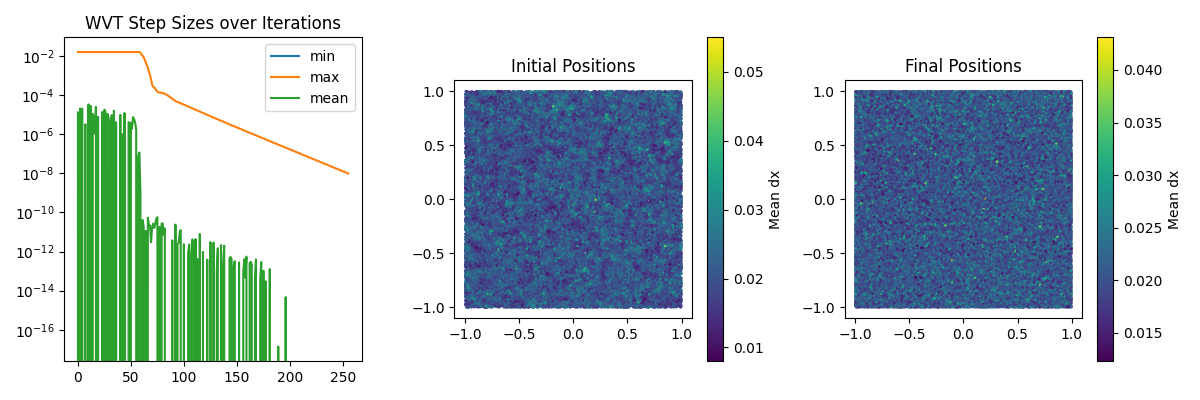

In [101]:
fig, axis = plt.subplots(1,3, figsize=(12,4), squeeze=False)

axis[0,0].plot([d.min() for d in dxs], label='min')
axis[0,0].plot([d.max() for d in dxs], label='max')
axis[0,0].plot([d.mean() for d in dxs], label='mean')
axis[0,0].set_yscale('log')
axis[0,0].set_title('WVT Step Sizes over Iterations')
axis[0,0].legend()

sc = axis[0,1].scatter(getPeriodicPositions(original_positions, domain)[:,0].cpu(), getPeriodicPositions(original_positions, domain)[:,1].cpu(), s=1, c = mean_dxs[0])
fig.colorbar(sc, ax=axis[0,1], label='Mean dx')
axis[0,1].set_title('Initial Positions')
axis[0,1].set_aspect('equal')

sc = axis[0,2].scatter(getPeriodicPositions(particleState.positions, domain)[:,0].cpu(), getPeriodicPositions(particleState.positions, domain)[:,1].cpu(), s=1, c = mean_dxs[-1])
fig.colorbar(sc, ax=axis[0,2], label='Mean dx')
axis[0,2].set_title('Final Positions')  
axis[0,2].set_aspect('equal')

fig.tight_layout()

In [102]:
import h5py
from datetime import datetime

os.makedirs('sampled_positions', exist_ok=True)

for i in (tq := tqdm(range(16))):
    tq.set_description(f'WVT Run {tq.n+1}/16')
    
    original_positions = sampledPositions.clone()
    original_positions = torch.rand_like(particles.positions) * (domain.max - domain.min) + domain.min

    dx = L / nx
    dxScaling = dx / (2 * np.pi)**(1/dim)
    # print(f'Particle spacing dx: {dx}')

    dx_r = lambda r: 1/(2 - torch.clamp(torch.linalg.norm(r, dim=-1), min = 0, max = 0.5)) * dx
    dx_r = lambda r: torch.where(torch.linalg.norm(r, dim=-1) < 0.5, 1/2, 1) * dx
    dx_r = lambda r: (2+torch.sin(np.pi *r[:,0])) * dx
    dx_r = lambda r: torch.ones_like(r[:,0]) * dx
    h_r = lambda r: volumeToSupport(dx_r(r)**dim, targetNeighbors, dim)

    mu_initial = 1e-3
    mu_decay = 0.95
    mu = mu_initial
    particleState.positions = original_positions.clone()
    positions = []
    dxs = []
    mean_dxs = []
    hs = []
    positions.append(original_positions.cpu().numpy())
    nIter = 256

    for i in (tqn := tqdm(range(nIter), leave = False)):
        
        dx_step, h, neighborhood,dx_mean = wvt_step(particleState, neighborhood)
        particleState.positions = particleState.positions + dx_step
        particleState.supports = h
        dxs.append(dx_step.cpu().numpy())
        mean_dxs.append(dx_mean.cpu().numpy())
        hs.append(h.cpu().numpy())
        positions.append(particleState.positions.cpu().numpy())

        mu *= mu_decay
        tqn.set_description(f'WVT Run {tq.n+1}/16, Step {i+1}/{nIter} max dx: {dx_step.abs().max():.4f} mean dx: {dx_step.abs().mean():.4f} ')
        # print(f'WVT Step {i+1}/{nIter}, max dx: {dx_step.abs().max()}, mean dx: {dx_step.abs().mean()}')
            
            

    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')


    with h5py.File(f'sampled_positions/wvt_sampled_positions_{nx}x{nx}_{nIter}iter_{timestamp}.h5', 'w') as f:
        f.attrs['description'] = 'Sampled particle positions using WVT'
        f.attrs['nx'] = nx
        f.attrs['nIter'] = nIter
        f.attrs['dx'] = dx
        f.create_dataset('positions', data = np.array(positions))
        f.create_dataset('dxs', data = np.array(dxs))
        

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

...

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

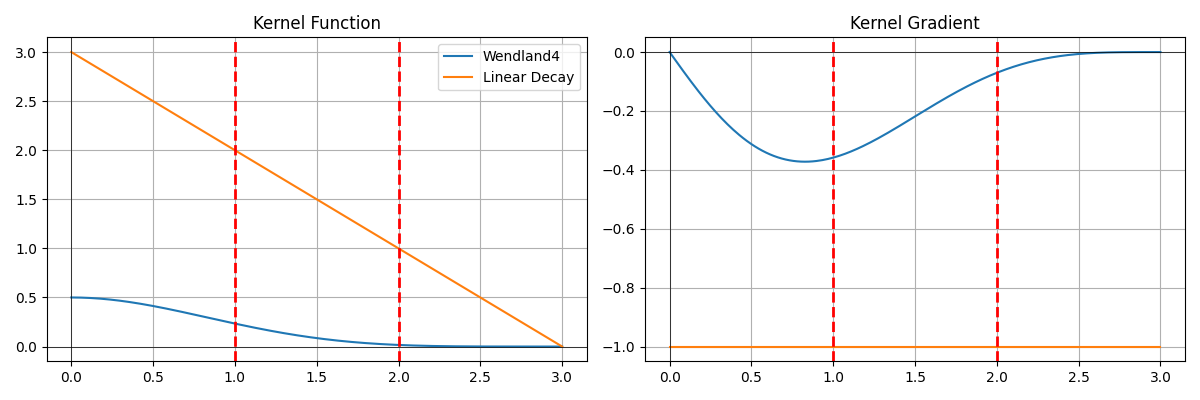

In [117]:
fig, axis = plt.subplots(1,2, figsize=(12,4), squeeze=False)

xx = torch.linspace(0,3,255)

W = Kernel(KernelType.Wendland4, xx.unsqueeze(1), torch.tensor([3.0]))

axis[0,0].plot(xx.cpu(), W.cpu(), label = 'Wendland4')
axis[0,0].plot(xx.cpu(), 3 - xx.cpu(), label = 'Linear Decay')
axis[0,0].grid(True)

from diffSPH.kernels import Kernel_Gradient
Wgrad = Kernel_Gradient(KernelType.Wendland4, xx.unsqueeze(1), torch.tensor([3.0]))
axis[0,1].plot(xx.cpu(), Wgrad.cpu(), label = 'Wendland4 Gradient')
axis[0,1].plot(xx.cpu(), -torch.ones_like(xx.cpu()), label = 'Constant Gradient')
axis[0,1].grid(True)

axis[0,0].set_title('Kernel Function')
axis[0,1].set_title('Kernel Gradient')
axis[0,0].legend()

for ax in axis.flatten():
    # ax.legend()
    ax.axhline(0, color='black', lw=0.5, ls='-')
    ax.axvline(0, color='black', lw=0.5, ls='-')
    
    ax.axvline(1.0, color='red', lw=2, ls='--')
    ax.axvline(2.0, color='red', lw=2, ls='--')
fig.tight_layout()



In [121]:
16.69 * Kernel_Gradient(KernelType.Wendland4, torch.tensor([[1.0]]), torch.tensor([3.0])) - 16.17 * Kernel_Gradient(KernelType.Wendland4, torch.tensor([[2.0]]), torch.tensor([3.0]))

tensor([[-4.8444]])

tensor([[-1.1386]])

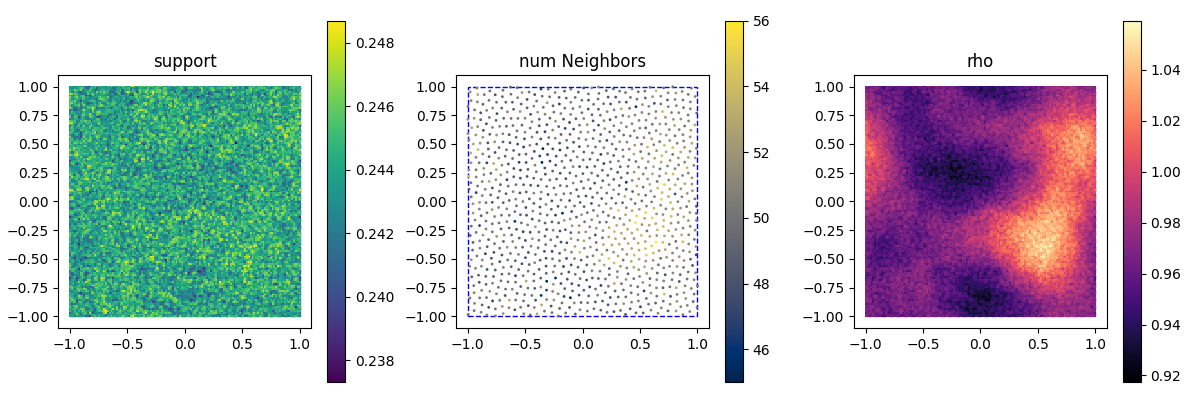

In [590]:
neighborhood, sparseNeighborhood_ = buildNeighborhood(particleState, particleState, domain, verletScale = 1.0, mode = 'gather', priorNeighborhood=None)
neighbors = computeNeighborhoodStates(particleState, sparseNeighborhood_, 'gather', kernel, kernel, True, False, False)
particleState.densities = computeDensity(particleState, kernel, neighbors.get('noghost'), SupportScheme.Gather, config)

num_Neighbors = coo_to_csr(neighbors.neighbors).rowEntries

fig, axis = plt.subplots(1,3 , figsize=(12,4), squeeze=False)
markerSize = 1
visualizeParticles(fig, axis[0,0], particleState, config['domain'], particleState.supports,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'viridis', 
    markerSize = markerSize, gridVisualization = True, title = 'support')

visualizeParticles(fig, axis[0,1], particleState, config['domain'], num_Neighbors,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'cividis', 
    markerSize = markerSize, gridVisualization = False, title = 'num Neighbors')

visualizeParticles(fig, axis[0,2], particleState, config['domain'], particleState.densities,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', 
    markerSize = markerSize, gridVisualization = True, title = 'rho', mapping = 'L2')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()
    

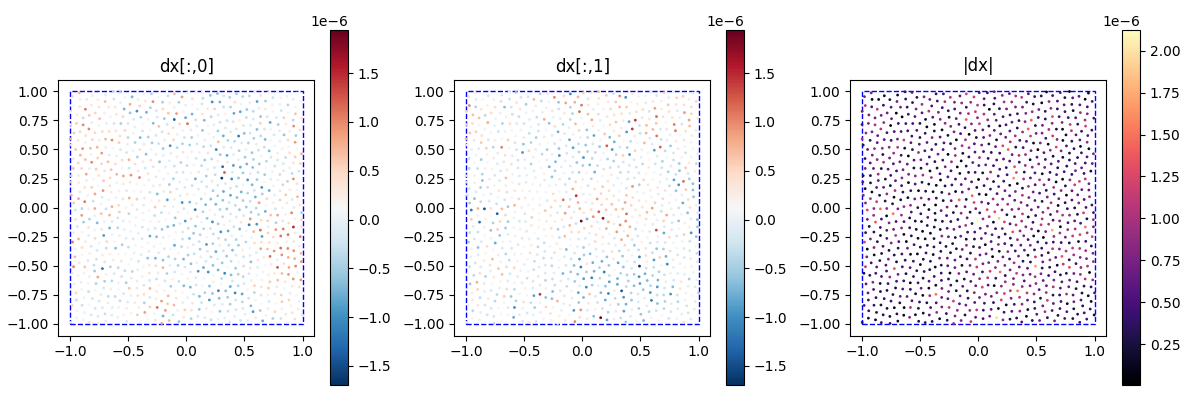

In [591]:
fig, axis = plt.subplots(1,3 , figsize=(12,4), squeeze=False)
markerSize = 1

dx_step = torch.tensor(dxs[-1]).to(device)
visualizeParticles(fig, axis[0,0], particleState, config['domain'], dx_step,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu_r', 
    markerSize = markerSize, gridVisualization = False, title = 'dx[:,0]', mapping = '.x', vmin = max(-dx_step.max(), dx_step.min()), vmax = max(dx_step.max(), -dx_step.min()))

visualizeParticles(fig, axis[0,1], particleState, config['domain'], dx_step,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'RdBu_r', 
    markerSize = markerSize, gridVisualization = False, title = 'dx[:,1]', mapping = '.y', vmin = max(-dx_step.max(), dx_step.min()), vmax = max(dx_step.max(), -dx_step.min()))

visualizeParticles(fig, axis[0,2], particleState, config['domain'], dx_step,
    kernel, which = 'both', visualizeBoth = True, cbar = True, cmap = 'magma', 
    markerSize = markerSize, gridVisualization = False, title = '|dx|', mapping = 'L2')

# plotDistribution(fig, axis[0,1], particleState, neighbors.get('noghost'), 63)
fig.tight_layout()

In [592]:
positions = particleState.positions.clone()

print(positions.shape)

torch.Size([1024, 2])


In [593]:
def parallel_distance_clustering_gpu(positions, coo_neighbors, patch_size):
    """
    Parallel clustering using distance matrices - no race conditions
    """
    device = positions.device
    n_particles = positions.shape[0]
    
    # Get edge distances
    row, col = coo_neighbors[0], coo_neighbors[1]
    distances = torch.norm(positions[row] - positions[col], dim=1)
    
    # Create sparse distance matrix
    n = positions.shape[0]
    dist_matrix = torch.full((n, n), float('inf'), device=device)
    dist_matrix[row, col] = distances
    dist_matrix[col, row] = distances  # symmetric
    dist_matrix.fill_diagonal_(0)
    
    # Find k-nearest neighbors for each particle
    k = min(patch_size - 1, n - 1)
    knn_distances, knn_indices = torch.topk(dist_matrix, k + 1, dim=1, largest=False)
    
    # Each particle proposes its own cluster (itself + k nearest neighbors)
    proposed_clusters = knn_indices[:, :patch_size]  # Shape: [n_particles, patch_size]
    
    # Score each proposed cluster (lower is better)
    cluster_scores = torch.sum(knn_distances[:, :patch_size], dim=1)
    
    # Resolve conflicts: for each particle, choose the best cluster it belongs to
    cluster_assignments = torch.full((n_particles,), -1, dtype=torch.long, device=device)
    
    # Process clusters in order of quality (best first)
    sorted_scores, sorted_indices = torch.sort(cluster_scores)
    
    for cluster_idx in sorted_indices:
        cluster_particles = proposed_clusters[cluster_idx]
        # Check if any particles in this cluster are already assigned
        if torch.any(cluster_assignments[cluster_particles] != -1):
            continue
        # Assign all particles in this cluster
        cluster_assignments[cluster_particles] = cluster_idx.item()
    
    # Handle unassigned particles
    unassigned = torch.where(cluster_assignments == -1)[0]
    cluster_counter = torch.max(cluster_assignments) + 1 if torch.any(cluster_assignments != -1) else 0
    
    for particle in unassigned:
        cluster_assignments[particle] = cluster_counter
        cluster_counter += 1
    
    # Compute cluster centers
    unique_clusters = torch.unique(cluster_assignments)
    cluster_positions = torch.stack([
        positions[cluster_assignments == cid].mean(dim=0) 
        for cid in unique_clusters
    ])
    
    return cluster_positions, cluster_assignments

In [594]:
def morton_parallel_clustering_gpu(positions, patch_size):
    """
    Morton code based clustering - naturally parallel
    """
    device = positions.device
    n_particles = positions.shape[0]
    
    # Normalize positions to integer coordinates
    pos_min = positions.min(dim=0)[0]
    pos_max = positions.max(dim=0)[0]
    pos_range = pos_max - pos_min
    
    # Scale to [0, 1023] for 10-bit Morton codes
    bits = 10
    normalized_pos = ((positions - pos_min) / pos_range * (2**bits - 1)).long()
    
    # Compute Morton codes (can be done in parallel)
    if positions.shape[1] == 2:
        morton_codes = morton_encode_2d_gpu(normalized_pos[:, 0], normalized_pos[:, 1])
    else:  # 3D
        morton_codes = morton_encode_3d_gpu(normalized_pos[:, 0], normalized_pos[:, 1], normalized_pos[:, 2])
    
    # Sort by Morton code
    sorted_indices = torch.argsort(morton_codes)
    
    # Assign clusters in parallel chunks
    n_clusters = (n_particles + patch_size - 1) // patch_size
    cluster_assignments = torch.arange(n_particles, device=device) // patch_size
    cluster_assignments = cluster_assignments[torch.argsort(sorted_indices)]
    
    # Compute cluster centers using scatter operations
    from torch_scatter import scatter_mean
    cluster_positions = scatter_mean(positions, cluster_assignments, dim=0)
    
    return cluster_positions, cluster_assignments

def morton_encode_2d_gpu(x, y):
    """GPU-optimized Morton encoding for 2D"""
    def part1by1(n):
        n = n & 0x0000ffff
        n = (n | (n << 8)) & 0x00ff00ff
        n = (n | (n << 4)) & 0x0f0f0f0f
        n = (n | (n << 2)) & 0x33333333
        n = (n | (n << 1)) & 0x55555555
        return n
    
    return part1by1(x) | (part1by1(y) << 1)

def morton_encode_3d_gpu(x, y, z):
    """GPU-optimized Morton encoding for 3D"""
    def part1by2(n):
        n = n & 0x000003ff
        n = (n | (n << 16)) & 0xff0000ff
        n = (n | (n << 8)) & 0x0300f00f
        n = (n | (n << 4)) & 0x030c30c3
        n = (n | (n << 2)) & 0x09249249
        return n
    
    return part1by2(x) | (part1by2(y) << 1) | (part1by2(z) << 2)

In [595]:
def grid_parallel_clustering_gpu(positions, domain, target_patch_size):
    """
    Grid-based clustering - embarrassingly parallel
    """
    device = positions.device
    n_particles = positions.shape[0]
    dim = positions.shape[1]
    
    # Calculate grid dimensions
    cells_per_dim = int((n_particles / target_patch_size) ** (1/dim)) + 1
    
    # Map positions to grid cells (parallel operation)
    domain_size = domain.max - domain.min
    cell_size = domain_size / cells_per_dim
    
    # Grid indices for each particle
    grid_indices = ((positions - domain.min) / cell_size).floor().long()
    grid_indices = torch.clamp(grid_indices, 0, cells_per_dim - 1)
    
    # Convert to flat cell IDs
    if dim == 2:
        cell_ids = grid_indices[:, 0] * cells_per_dim + grid_indices[:, 1]
    else:  # 3D
        cell_ids = (grid_indices[:, 0] * cells_per_dim + grid_indices[:, 1]) * cells_per_dim + grid_indices[:, 2]
    
    # Compute cluster centers using scatter operations
    from torch_scatter import scatter_mean
    unique_cells, inverse_indices = torch.unique(cell_ids, return_inverse=True)
    cluster_positions = scatter_mean(positions, inverse_indices, dim=0)
    
    return cluster_positions, inverse_indices

Original particles: 1024
Patch positions: 424
Connectivity shape: torch.Size([2, 1024])


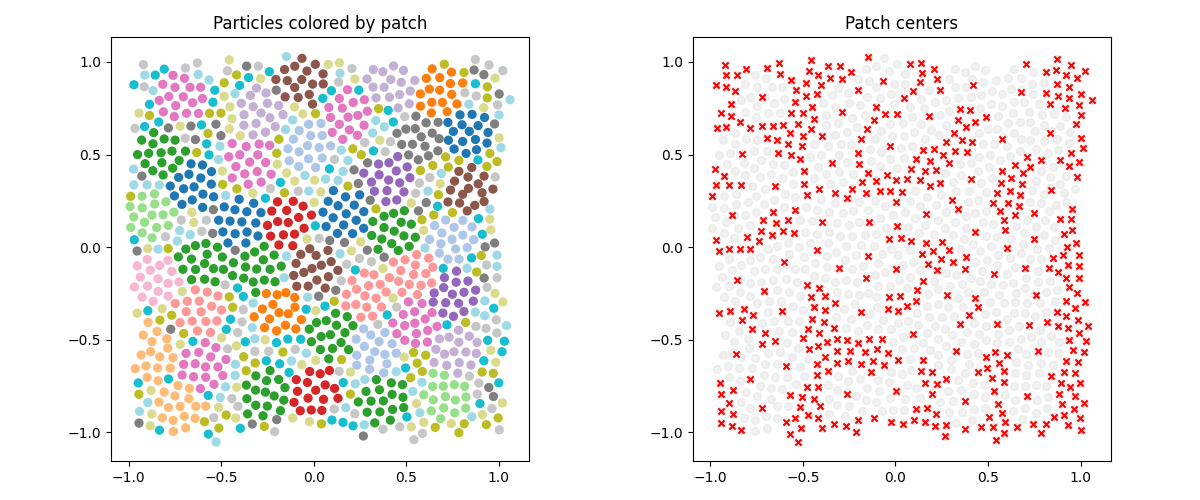

In [599]:
# Add this to your notebook after the WVT optimization

def patch_particles_parallel(particleState, neighbors, patch_size=16, method='morton'):
    """
    Create patches using parallel GPU-native methods
    """
    if method == 'morton':
        patch_positions, cluster_assignments = morton_parallel_clustering_gpu(
            particleState.positions, patch_size
        )
    elif method == 'grid':
        patch_positions, cluster_assignments = grid_parallel_clustering_gpu(
            particleState.positions, domain, patch_size
        )
    elif method == 'distance':
        neighs = neighbors.get('noghost')
        coo_neighbors = torch.stack([neighs[0].row, neighs[0].col])
        patch_positions, cluster_assignments = parallel_distance_clustering_gpu(
            particleState.positions, coo_neighbors, patch_size
        )
    
    # Create connectivity in COO format [patch_id, particle_id]
    particle_ids = torch.arange(particleState.positions.shape[0], device=particleState.positions.device)
    connectivity = torch.stack([cluster_assignments, particle_ids])
    
    return patch_positions, connectivity, cluster_assignments

# Usage after your WVT optimization:
patch_positions, patch_connectivity, cluster_assignments = patch_particles_parallel(
    particleState, neighbors, patch_size=16, method='distance'
)

print(f"Original particles: {particleState.positions.shape[0]}")
print(f"Patch positions: {patch_positions.shape[0]}")
print(f"Connectivity shape: {patch_connectivity.shape}")

# Visualize
fig, axis = plt.subplots(1, 2, figsize=(12, 5))

# Particles colored by cluster
sc = axis[0].scatter(particleState.positions[:,0].cpu(), particleState.positions[:,1].cpu(), 
                    s=32, c=cluster_assignments.cpu(), cmap='tab20')
axis[0].set_title('Particles colored by patch')
axis[0].set_aspect('equal')

# Patch centers
axis[1].scatter(particleState.positions[:,0].cpu(), particleState.positions[:,1].cpu(), 
               s=32, c='lightgray', alpha=0.3)
axis[1].scatter(patch_positions[:,0].cpu(), patch_positions[:,1].cpu(), 
               s=20, c='red', marker='x')
axis[1].set_title('Patch centers')
axis[1].set_aspect('equal')

plt.tight_layout()